In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2

from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10

In [2]:
(x_train, _), (x_test, _) = cifar10.load_data()

print("Training images:", x_train.shape)
print("Testing images:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Training images: (50000, 32, 32, 3)
Testing images: (10000, 32, 32, 3)


In [3]:
def get_edges(images):
    edges = []

    for img in images:
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        edge = cv2.Canny(gray, 100, 200)
        edge = edge / 255.0
        edge = np.expand_dims(edge, axis=-1)
        edges.append(edge)

    return np.array(edges)

x_train_edges = get_edges(x_train)
x_test_edges = get_edges(x_test)

print(x_train_edges.shape)

(50000, 32, 32, 1)


In [4]:
x_train = (x_train / 127.5) - 1
x_test = (x_test / 127.5) - 1

x_train_edges = (x_train_edges * 2) - 1
x_test_edges = (x_test_edges * 2) - 1

In [5]:
def build_model():

    inputs = layers.Input(shape=(32,32,1))

    # Encoder
    x = layers.Conv2D(64,3,strides=2,padding='same',activation='relu')(inputs)
    x = layers.Conv2D(128,3,strides=2,padding='same',activation='relu')(x)
    x = layers.Conv2D(256,3,strides=2,padding='same',activation='relu')(x)

    # Decoder
    x = layers.Conv2DTranspose(128,3,strides=2,padding='same',activation='relu')(x)
    x = layers.Conv2DTranspose(64,3,strides=2,padding='same',activation='relu')(x)
    x = layers.Conv2DTranspose(3,3,strides=2,padding='same',activation='tanh')(x)

    model = models.Model(inputs,x)

    return model

model = build_model()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 16, 16, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 8, 8, 128)      │       295,040 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 16, 16, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 32, 32, 3)      │         1,731 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 740,227 (2.82 MB)

 Trainable params: 740,227 (2.82 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
model.compile(
    optimizer='adam',
    loss='mse'
)

In [7]:
history = model.fit(
    x_train_edges,
    x_train,
    epochs=10,
    batch_size=64,
    validation_data=(x_test_edges, x_test)
)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - loss: 0.2449 - val_loss: 0.2363
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.2364 - val_loss: 0.2337
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.2339 - val_loss: 0.2329
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.2287 - val_loss: 0.2323
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.2237 - val_loss: 0.2328
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.2180 - val_loss: 0.2366
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.2080 - val_loss: 0.2397
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.1994 - val_loss: 0.2481
Epoch 9/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.1901 - val_loss: 0.2501
Epoch 10/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.1824 - val_loss: 0.2592


In [8]:
predictions = model.predict(x_test_edges[:10])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 618ms/step


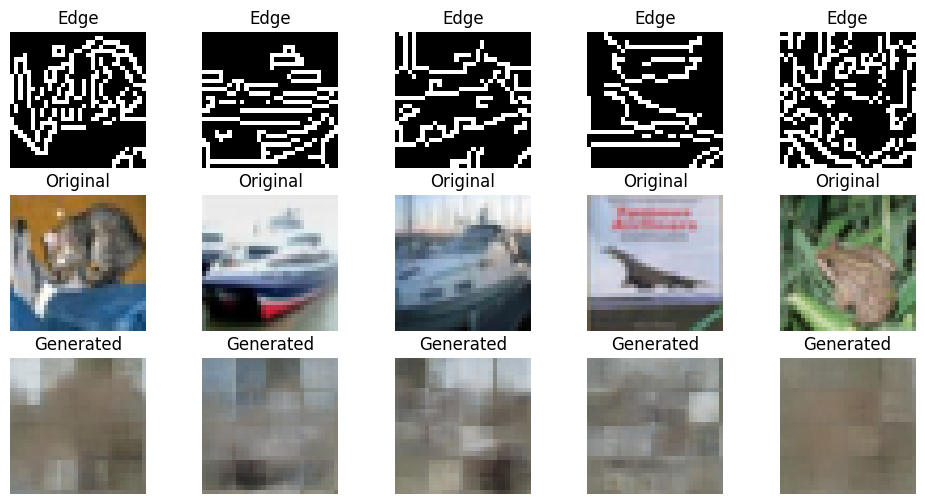

In [9]:
plt.figure(figsize=(12,6))

for i in range(5):

    # Edge input
    plt.subplot(3,5,i+1)
    plt.imshow(x_test_edges[i].squeeze(), cmap='gray')
    plt.title("Edge")
    plt.axis("off")

    # Original image
    plt.subplot(3,5,i+6)
    plt.imshow((x_test[i]+1)/2)
    plt.title("Original")
    plt.axis("off")

    # Generated image
    plt.subplot(3,5,i+11)
    plt.imshow((predictions[i]+1)/2)
    plt.title("Generated")
    plt.axis("off")

plt.show()